# <b>Log(P) Prediction with a CNN</b>

Tutorial: https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch

### Import Libraries

In [71]:
### data-handling and visualisation
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [62]:
### rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

In [89]:
### PyTorch
import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

import torchvision

import torchmetrics

## 1 | Load Data

In [80]:
# load data
logPdata = pd.read_csv('logP_dataset.csv', names=['SMILES', 'ClogP'])

In [82]:
# split into training and testing datasets
split_data = sklearn.model_selection.train_test_split(
    logPdata, test_size=0.1, shuffle=True
    )

test, train = split_data[0], split_data[1]

(test.shape, train.shape)

((13149, 2), (1461, 2))

#### 1.1 | Visualise SMILES

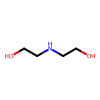

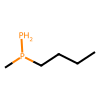

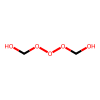

In [ ]:
# create list of SMILES
SMILES_list = logPdata['SMILES'].values.tolist()

# create Mol objects from SMILES
ms = [Chem.MolFromSmiles(smi) for smi in SMILES_list[9:12]]

# visualise Mol objects
for m in ms:
    img = Draw.MolToImage(m, size=(100,100))
    display(img)

## 2 | Train CNN

In [85]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84,10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*5*5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
net = Net()

In [86]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [93]:
trainloader = torch.utils.data.DataLoader(train, batch_size=4,
                                          shuffle=True, num_workers=2)

In [94]:
for epoch in range(2):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimiser.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\Daniel K\miniconda3\envs\venv_science\Lib\site-packages\pandas\core\indexes\base.py", line 3812, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7096, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 1114

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Daniel K\miniconda3\envs\venv_science\Lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)

In [91]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True)

100%|██████████| 170M/170M [09:25<00:00, 301kB/s]  


In [92]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train